### Imports

In [1]:
import sys
sys.path.insert(0, "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection")

import torch
import requests
import json as json_module
import os
import cv2

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from dataclasses import dataclass, replace
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# CB Loss ve Training Logger
from src.cb_loss import compute_class_counts_from_coco, compute_cb_weights
from src.training_logger import TrainingLogger, ExcelLoggerCallback

## Fine-tune RT-DETR on custom dataset

In [2]:
# @title Configuration

DATASET_PATH = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/merged_thermal_coco_augmented"
CHECKPOINT = "PekingU/rtdetr_r18vd"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Dataset path: {DATASET_PATH}")
print(f"Checkpoint: {CHECKPOINT}")
print(f"Device: {DEVICE}")

Dataset path: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/merged_thermal_coco_augmented
Checkpoint: PekingU/rtdetr_r18vd
Device: cuda


In [3]:
class LazyCOCODataset:
    """sv.DetectionDataset drop-in replacement that loads images lazily."""

    def __init__(self, images_directory_path, annotations_path):
        with open(annotations_path, 'r') as f:
            coco = json_module.load(f)

        # Category mapping: COCO cat_id -> 0-indexed
        sorted_cats = sorted(coco['categories'], key=lambda x: x['id'])
        self._classes = [cat['name'] for cat in sorted_cats]
        self._cat_id_to_idx = {cat['id']: idx for idx, cat in enumerate(sorted_cats)}

        # Image info
        self._images_dir = images_directory_path
        self._image_ids = []
        self._image_info = {}
        for img in coco['images']:
            self._image_ids.append(img['id'])
            self._image_info[img['id']] = img

        # Group annotations by image_id
        self._annotations = {}
        for ann in coco['annotations']:
            self._annotations.setdefault(ann['image_id'], []).append(ann)

    @property
    def classes(self):
        return self._classes

    def __len__(self):
        return len(self._image_ids)

    def __getitem__(self, idx):
        image_id = self._image_ids[idx]
        img_info = self._image_info[image_id]
        image_path = os.path.join(self._images_dir, img_info['file_name'])

        # Load image lazily
        image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

        # Thermal images: grayscale -> 3 kanal BGR
        if image.ndim == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        # Parse annotations
        anns = self._annotations.get(image_id, [])
        boxes, class_ids = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            class_ids.append(self._cat_id_to_idx[ann['category_id']])

        xyxy = np.array(boxes, dtype=np.float32) if boxes else np.empty((0, 4), dtype=np.float32)
        cid = np.array(class_ids, dtype=int) if class_ids else np.empty(0, dtype=int)

        detections = sv.Detections(xyxy=xyxy, class_id=cid)
        return image_path, image, detections


ds_train = LazyCOCODataset(
    images_directory_path=f"{DATASET_PATH}/train/images",
    annotations_path=f"{DATASET_PATH}/train/_annotations.coco.json",
)
ds_valid = LazyCOCODataset(
    images_directory_path=f"{DATASET_PATH}/val/images",
    annotations_path=f"{DATASET_PATH}/val/_annotations.coco.json",
)
ds_test = LazyCOCODataset(
    images_directory_path=f"{DATASET_PATH}/test/images",
    annotations_path=f"{DATASET_PATH}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 62854
Number of validation images: 5964
Number of test images: 2387


In [4]:
# @title Class-Balanced agirliklari hesapla

class_names, class_counts = compute_class_counts_from_coco(
    f"{DATASET_PATH}/train/_annotations.coco.json"
)

print("Sinif dagilimi:")
for name, count in zip(class_names, class_counts):
    print(f"  {name}: {count:,}")

cb_weights = compute_cb_weights(class_counts, beta=0.99999)
print(f"\nCB weights (beta=0.9999):")
for name, w in zip(class_names, cb_weights.tolist()):
    print(f"  {name}: {w:.4f}")

Sinif dagilimi:
  Person: 335,428
  Car: 577,119
  OtherVehicle: 36,186

CB weights (beta=0.9999):
  Person: 0.5829
  Car: 0.5643
  OtherVehicle: 1.8528


In [5]:
IMAGE_SIZE = 512

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [6]:
# Dataset zaten augmented, ekstra augmentation uygulanmiyor

train_augmentation_and_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [7]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Thermal: grayscale -> 3 kanal, sonra BGR -> RGB
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)
        else:
            image = image[:, :, ::-1].copy()
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [8]:
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.3569, 0.3059, 0.2706,  ..., 0.2902, 0.2902, 0.2902],
          [0.4353, 0.4235, 0.4118,  ..., 0.2941, 0.2902, 0.2902],
          [0.5686, 0.5922, 0.6000,  ..., 0.3059, 0.2980, 0.2980],
          ...,
          [0.7608, 0.7569, 0.7647,  ..., 0.1843, 0.1922, 0.1961],
          [0.7529, 0.7608, 0.7765,  ..., 0.1882, 0.1843, 0.1804],
          [0.7490, 0.7647, 0.7843,  ..., 0.2000, 0.1882, 0.1804]],
 
         [[0.3569, 0.3059, 0.2706,  ..., 0.2902, 0.2902, 0.2902],
          [0.4353, 0.4235, 0.4118,  ..., 0.2941, 0.2902, 0.2902],
          [0.5686, 0.5922, 0.6000,  ..., 0.3059, 0.2980, 0.2980],
          ...,
          [0.7608, 0.7569, 0.7647,  ..., 0.1843, 0.1922, 0.1961],
          [0.7529, 0.7608, 0.7765,  ..., 0.1882, 0.1843, 0.1804],
          [0.7490, 0.7647, 0.7843,  ..., 0.2000, 0.1882, 0.1804]],
 
         [[0.3569, 0.3059, 0.2706,  ..., 0.2902, 0.2902, 0.2902],
          [0.4353, 0.4235, 0.4118,  ..., 0.2941, 0.2902, 0.2902],
          [0.5686, 0.592

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [9]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [10]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [11]:
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

Loading weights: 100%|██████████| 526/526 [00:00<00:00, 3526.31it/s]
[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r18vd
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([3])          
model.denoising_class_embed.weight         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([4, 256])
model.decoder.class_embed.{0, 1, 2}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([3, 256])
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([3]

In the [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments) use `output_dir` to specify where to save your model, then configure hyperparameters as you see fit. For `num_train_epochs=10` training will take about 15 minutes in Google Colab T4 GPU, increase the number of epoch to get better results.

Important notes:

- Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to `False`.
- Set `eval_do_concat_batches=False` to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [12]:
training_args = TrainingArguments(
    output_dir="thermal-detection-finetune",
    num_train_epochs=100,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [13]:
# @title Training Logger baslat

EXCEL_OUTPUT = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/detr/training_results_rtdetr.xlsx"

training_logger = TrainingLogger(
    output_path=EXCEL_OUTPUT,
    model_name="RT-DETR-r18vd-thermal",
)
print(f"Excel cikti: {EXCEL_OUTPUT}")

Excel cikti: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/detr/training_results_rtdetr.xlsx


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    processing_class=processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
    callbacks=[ExcelLoggerCallback(training_logger)],
)

trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## Evaluate

In [ ]:
# @title Collect predictions

targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [ ]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.89
map50: 0.94
map75: 0.94


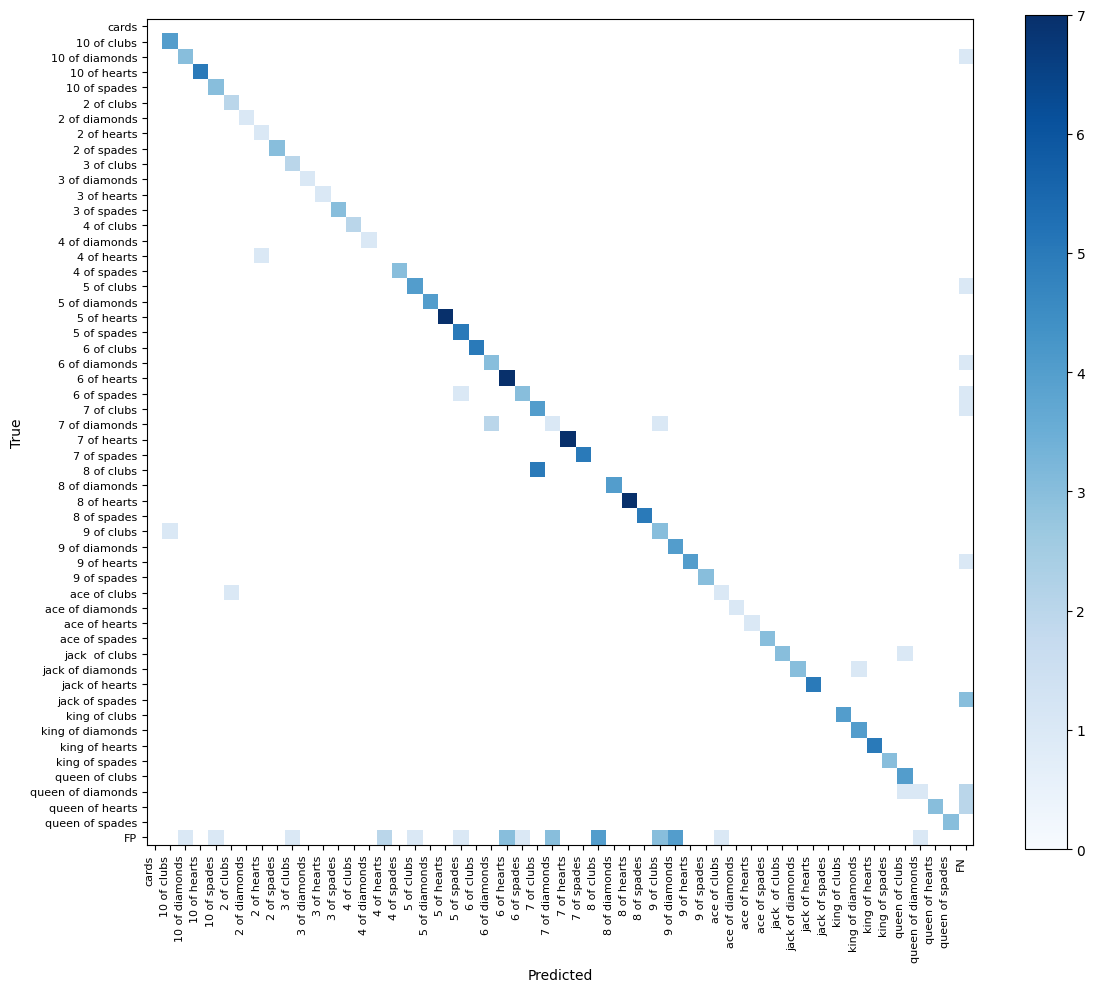

In [ ]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

In [ ]:
# @title Confusion matrix ve metrikleri Excel'e kaydet

training_logger.log_confusion_matrix(
    matrix=confusion_matrix.matrix.tolist(),
    class_names=ds_test.classes,
)
training_logger.save()
print(f"Tum metrikler kaydedildi: {EXCEL_OUTPUT}")

## Save fine-tuned model on hard drive

In [ ]:
model.save_pretrained("/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/detr")
processor.save_pretrained("/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/detr")

['/content/rt-detr/preprocessor_config.json']